# Time Series Regression: Trend and Seasonality Modeling
## Data Science and Analytics Track

---

**Objective:** Extend regression modeling to capture time-based patterns in retail sales data.
Build, compare, and evaluate a Linear Regression baseline against Polynomial Regression models
that explicitly model trend curvature and seasonal cycles.

**Dataset:** Store Sales - Time Series Forecasting (Corporación Favorita, Ecuador)
Source: https://www.kaggle.com/competitions/store-sales-time-series-forecasting

**Files Required:**
- `train.csv` - Daily sales records across all stores and product families
- `holidays_events.csv` - National holiday dates for seasonality features

**Models Built:**
- Baseline Linear Regression (trend only)
- Linear Regression with full feature set
- Polynomial Regression degree 2
- Polynomial Regression degree 3

**Evaluation Metrics:** MAE, RMSE, R-squared, MAPE

**Tech Stack:** Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn


---
## Section 1: Library Imports


In [147]:
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.4f}".format)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "lines.linewidth": 1.8,
    "figure.dpi": 100,
})

print("Libraries loaded successfully.")
print(f"  pandas     : {pd.__version__}")
print(f"  numpy      : {np.__version__}")
print(f"  scikit-learn: imported")

Libraries loaded successfully.
  pandas     : 2.2.2
  numpy      : 1.26.4
  scikit-learn: imported


---
## Section 2: Project Configuration

All file paths and hyperparameters are defined here in one place.
If you rename your folder or move your files, only this cell needs updating.


In [148]:
BASE_DIR       = "."
TRAIN_PATH     = os.path.join(BASE_DIR, "train.csv")
HOLIDAYS_PATH  = os.path.join(BASE_DIR, "holidays_events.csv")

# Output directory for charts and saved models
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs_2")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Modeling parameters
RANDOM_SEED = 42
TEST_SIZE    = 0.20
CV_SPLITS    = 5

print("File check:")
for label, path in [("train.csv", TRAIN_PATH), ("holidays_events.csv", HOLIDAYS_PATH)]:
    status = "FOUND" if os.path.exists(path) else "MISSING — download from Kaggle"
    print(f"  [{status}]  {label}")

print(f"\nOutput directory: {OUTPUT_DIR}")

File check:
  [FOUND]  train.csv
  [FOUND]  holidays_events.csv

Output directory: .\outputs_2


---
## Section 3: Time Series Concepts

Before modeling, it is essential to understand what we are trying to capture.

### Components of a Time Series

A time series observation y(t) is typically decomposed into four components:

```
y(t) = Trend(t) + Seasonality(t) + Cyclicality(t) + Noise(t)
```

**Trend**
The long-term direction of the data. In retail, sales typically grow over time
due to store expansion, inflation, and market growth. Linear regression captures
a constant-rate trend. Polynomial regression captures an accelerating or
decelerating trend.

**Seasonality**
Regular, repeating patterns at fixed intervals.
- Weekly seasonality: people shop differently on weekdays vs weekends
- Monthly seasonality: pay cycles, promotions, school calendars
- Annual seasonality: holidays, festive seasons, weather

**Cyclicality**
Long-term waves not tied to a fixed calendar period (e.g., economic cycles).
Not modeled in this project.

**Noise**
Random, unpredictable fluctuation. No model can or should capture noise.

---

### Why Linear Regression Alone Is Insufficient for Time Series

A standard linear regression assumes:

```
y = beta_0 + beta_1 * t
```

This captures only a constant-rate trend. It cannot model:
- Accelerating or decelerating growth (requires polynomial terms)
- Monthly cycles (requires month indicators or sine/cosine encoding)
- Weekly cycles (requires weekday indicators)
- Holiday spikes (requires binary flags)

This project adds all of the above to close that gap.

---

### Cyclical Feature Encoding

A naive approach encodes month as integers 1–12. This implies December (12) is
"farther" from January (1) than March (3) is, which is statistically incorrect
because December and January are adjacent in the annual cycle.

The correct approach is sine/cosine encoding:

```
month_sin = sin(2 * pi * month / 12)
month_cos = cos(2 * pi * month / 12)
```

This maps the 12 months onto a circle, preserving the adjacency of December
and January. The same approach applies to days of the week with period 7.

---

### Polynomial Regression

Polynomial regression extends linear regression by adding powered terms of the
time index as additional features:

```
Degree 1 (linear)    : y = b0 + b1*t
Degree 2 (quadratic) : y = b0 + b1*t + b2*t^2
Degree 3 (cubic)     : y = b0 + b1*t + b2*t^2 + b3*t^3
```

Scikit-learn's `PolynomialFeatures` transforms the input matrix to include all
polynomial terms up to the specified degree. The resulting matrix is then passed
to a standard `LinearRegression` estimator.

Higher degrees fit training data more closely but risk **overfitting** — learning
noise rather than signal. We use the test set and cross-validation to detect this.


---
## Section 4: Data Loading


In [149]:
print("Loading train.csv  (approx 200 MB — allow 30-60 seconds)...")
train_raw = pd.read_csv(
    TRAIN_PATH,
    parse_dates=["date"],
    dtype={"store_nbr": "int8", "onpromotion": "int32"},
)
print(f"  train.csv loaded    -> shape: {train_raw.shape}")

print("Loading holidays_events.csv...")
holidays_raw = pd.read_csv(HOLIDAYS_PATH, parse_dates=["date"])
print(f"  holidays_events.csv -> shape: {holidays_raw.shape}")


Loading train.csv  (approx 200 MB — allow 30-60 seconds)...
  train.csv loaded    -> shape: (3000888, 6)
Loading holidays_events.csv...
  holidays_events.csv -> shape: (350, 6)


In [150]:
print("train.csv — first 6 rows:")
display(train_raw.head(6))

print(f"\nDate range  : {train_raw['date'].min().date()}  to  {train_raw['date'].max().date()}")
print(f"Unique stores  : {train_raw['store_nbr'].nunique()}")
print(f"Unique families: {train_raw['family'].nunique()}")
print(f"Total records  : {len(train_raw):,}")


train.csv — first 6 rows:


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0000,0
1,1,2013-01-01,1,BABY CARE,0.0000,0
2,2,2013-01-01,1,BEAUTY,0.0000,0
3,3,2013-01-01,1,BEVERAGES,0.0000,0
4,4,2013-01-01,1,BOOKS,0.0000,0
5,5,2013-01-01,1,BREAD/BAKERY,0.0000,0



Date range  : 2013-01-01  to  2017-08-15
Unique stores  : 54
Unique families: 33
Total records  : 3,000,888


In [151]:
print("holidays_events.csv — first 8 rows:")
display(holidays_raw.head(8))

print(f"\nLocale types : {list(holidays_raw['locale'].unique())}")
print(f"Holiday types: {list(holidays_raw['type'].unique())}")


holidays_events.csv — first 8 rows:


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
5,2012-05-12,Holiday,Local,Puyo,Cantonizacion del Puyo,False
6,2012-06-23,Holiday,Local,Guaranda,Cantonizacion de Guaranda,False
7,2012-06-25,Holiday,Regional,Imbabura,Provincializacion de Imbabura,False



Locale types : ['Local', 'Regional', 'National']
Holiday types: ['Holiday', 'Transfer', 'Additional', 'Bridge', 'Work Day', 'Event']


---
## Section 5: Exploratory Data Analysis


In [152]:
# Missing value audit
print("Missing values — train.csv:")
missing_train = train_raw.isnull().sum()
print(missing_train[missing_train > 0].to_string() if missing_train.sum() > 0 else "  None found.")

print("\nMissing values — holidays_events.csv:")
missing_hol = holidays_raw.isnull().sum()
print(missing_hol[missing_hol > 0].to_string() if missing_hol.sum() > 0 else "  None found.")


Missing values — train.csv:
  None found.

Missing values — holidays_events.csv:
  None found.


In [153]:
# Sales distribution overview
print("Sales column — descriptive statistics (raw, all rows):")
display(train_raw["sales"].describe().to_frame().T)

zero_pct = (train_raw["sales"] == 0).mean() * 100
print(f"\nZero-sales rows : {(train_raw['sales'] == 0).sum():,}  ({zero_pct:.1f}%)")
print("Note: Zero-sale rows reflect store-family combinations with no sales that day.")
print("They are valid data points and are included in the daily aggregation.")


Sales column — descriptive statistics (raw, all rows):


,count,mean,std,min,25%,50%,75%,max
sales,3000888.0000,357.7757,1101.9977,0.0000,0.0000,11.0000,195.8473,124717.0000



Zero-sales rows : 939,130  (31.3%)
Note: Zero-sale rows reflect store-family combinations with no sales that day.
They are valid data points and are included in the daily aggregation.


In [154]:
# Top product families by average daily sales
family_avg = (
    train_raw.groupby("family")["sales"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
print("Top 10 product families by average sales:")
display(family_avg.head(10))


Top 10 product families by average sales:


,family,sales
0,GROCERY I,3776.9721
1,BEVERAGES,2385.7932
2,PRODUCE,1349.3521
3,CLEANING,1072.4167
4,DAIRY,709.1549
5,BREAD/BAKERY,463.3363
6,POULTRY,350.5323
7,MEATS,341.8500
8,PERSONAL CARE,270.4325
9,DELI,265.1351


---
## Section 6: Preprocessing and Daily Aggregation

**Strategy:** The raw dataset has one row per store per product family per day,
totaling approximately 3 million rows. For a regression model focused on
national trend and seasonality, we aggregate to one row per day.

This reduces the dataset to approximately 1,688 rows (Jan 2013 – Aug 2017),
where each row represents the total sales across all 54 stores and all product
families on that date.

**Aggregation columns:**
- `total_sales` = sum of all store-family sales for the day
- `total_promotions` = sum of all promotional items for the day

**Holiday processing:**
We use national-scope holidays only. Transferred holidays (where the actual
observation day was moved) are identified by `type == "Transfer"` and are
retained as real holiday dates. Original holidays marked `transferred == True`
are excluded.


In [155]:
# Step 1: Aggregate train.csv to daily totals
print("Aggregating to daily level...")

daily = (
    train_raw
    .groupby("date")
    .agg(
        total_sales      = ("sales",       "sum"),
        total_promotions = ("onpromotion", "sum"),
    )
    .reset_index()
    .sort_values("date")
    .reset_index(drop=True)
)

print(f"  Daily aggregation complete.")
print(f"  Shape: {daily.shape}  (one row per day)")
print(f"  Date range: {daily['date'].min().date()}  to  {daily['date'].max().date()}")
display(daily.head(6))


Aggregating to daily level...
  Daily aggregation complete.
  Shape: (1684, 3)  (one row per day)
  Date range: 2013-01-01  to  2017-08-15


,date,total_sales,total_promotions
0,2013-01-01,2511.6190,0
1,2013-01-02,496092.4179,0
2,2013-01-03,361461.2311,0
3,2013-01-04,354459.6771,0
4,2013-01-05,477350.1212,0
5,2013-01-06,519695.4011,0


In [156]:
# Step 2: Process national holidays
national = holidays_raw[holidays_raw["locale"] == "National"].copy()

real_holidays = national[
    ~((national["type"] == "Holiday") & (national["transferred"] == True))
][["date"]].drop_duplicates()

real_holidays["is_holiday"] = 1

print(f"National holiday dates after transfer correction: {len(real_holidays)}")
display(real_holidays.head(8))


National holiday dates after transfer correction: 160


,date,is_holiday
14,2012-08-10,1
20,2012-10-12,1
21,2012-11-02,1
22,2012-11-03,1
31,2012-12-21,1
33,2012-12-22,1
34,2012-12-23,1
35,2012-12-24,1


In [157]:
# Step 3: Merge holidays into daily frame
daily = daily.merge(real_holidays, on="date", how="left")
daily["is_holiday"] = daily["is_holiday"].fillna(0).astype(int)

print(f"Daily frame shape after merge: {daily.shape}")
print(f"Holiday days in dataset: {daily['is_holiday'].sum()}")
print(f"Missing values: {daily.isnull().sum().sum()}")
display(daily.head(6))


Daily frame shape after merge: (1684, 4)
Holiday days in dataset: 136
Missing values: 0


,date,total_sales,total_promotions,is_holiday
0,2013-01-01,2511.6190,0,1
1,2013-01-02,496092.4179,0,0
2,2013-01-03,361461.2311,0,0
3,2013-01-04,354459.6771,0,0
4,2013-01-05,477350.1212,0,1
5,2013-01-06,519695.4011,0,0


---
## Section 7: Time Series Feature Engineering

Features are organized into five groups, each capturing a distinct signal.

**Group 1 — Trend Features**
`time_index` encodes the passage of time as an integer (days since start).
This is the primary input to polynomial regression.

**Group 2 — Calendar Features**
Integers extracted from the date: year, month, day, quarter.
Year captures multi-year growth. Quarter captures coarse seasonality.

**Group 3 — Cyclical Seasonality Features (Sine/Cosine Encoding)**
Encodes month and day-of-week as smooth circular variables.
This is the statistically correct treatment of cyclical features.
A raw integer encoding would imply, incorrectly, that December and January
are far apart when they are in fact adjacent.

**Group 4 — Binary Event Indicators**
Weekend flag, holiday flag, month-start and month-end flags.
These capture discrete behavioral shifts at known calendar boundaries.

**Group 5 — Promotion Features**
`log_promotions` = log(1 + total_promotions) reduces right-skew.
`promo_rolling7` = 7-day rolling mean of promotions captures promotional buildup.


In [158]:
df = daily.copy()

# ── Group 1: Trend features ───
df["time_index"]    = (df["date"] - df["date"].min()).dt.days
df["time_index_sq"] = df["time_index"] ** 2

# ── Group 2: Calendar features ───
df["year"]         = df["date"].dt.year
df["month"]        = df["date"].dt.month
df["day"]          = df["date"].dt.day
df["quarter"]      = df["date"].dt.quarter
df["day_of_week"]  = df["date"].dt.dayofweek   # 0 = Monday, 6 = Sunday
df["day_of_year"]  = df["date"].dt.dayofyear
df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)

# ── Group 3: Cyclical seasonality encoding ───
# Monthly cycle (period = 12)
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# Weekly cycle (period = 7)
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

# Annual cycle (period = 365.25)
df["day_of_year_sin"] = np.sin(2 * np.pi * df["day_of_year"] / 365.25)
df["day_of_year_cos"] = np.cos(2 * np.pi * df["day_of_year"] / 365.25)

# Quarterly cycle (period = 4)
df["quarter_sin"] = np.sin(2 * np.pi * df["quarter"] / 4)
df["quarter_cos"] = np.cos(2 * np.pi * df["quarter"] / 4)

# ── Group 4: Binary event indicators ───
df["is_weekend"]     = (df["day_of_week"] >= 5).astype(int)
df["is_month_start"] = df["date"].dt.is_month_start.astype(int)
df["is_month_end"]   = df["date"].dt.is_month_end.astype(int)
# is_holiday already present from merge

# ── Group 5: Promotion feature available at inference time ───
df["log_promotions"] = np.log1p(df["total_promotions"])

print("Feature engineering complete.")
print(f"Dataset shape: {df.shape}")
print(f"\nNew columns added:")
new_cols = [c for c in df.columns if c not in ["date", "total_sales", "total_promotions", "is_holiday"]]
for i, col in enumerate(new_cols, 1):
    print(f"  {i:2}. {col}")

Feature engineering complete.
Dataset shape: (1684, 25)

New columns added:
   1. time_index
   2. time_index_sq
   3. year
   4. month
   5. day
   6. quarter
   7. day_of_week
   8. day_of_year
   9. week_of_year
  10. month_sin
  11. month_cos
  12. dow_sin
  13. dow_cos
  14. day_of_year_sin
  15. day_of_year_cos
  16. quarter_sin
  17. quarter_cos
  18. is_weekend
  19. is_month_start
  20. is_month_end
  21. log_promotions


In [159]:
# Verify no NaN values were introduced
na_check = df.isnull().sum()
if na_check.sum() == 0:
    print("No missing values after feature engineering.")
else:
    print("Missing values detected:")
    print(na_check[na_check > 0])

# Summary statistics of engineered features
display(df.describe().T[["mean", "std", "min", "max"]].round(4))


No missing values after feature engineering.


,mean,std,min,max
date,2015-04-24 08:27:04.703088128,NaN,2013-01-01 00:00:00,2017-08-15 00:00:00
total_sales,637556.3849,234410.2437,2511.6190,1463083.9625
total_promotions,4638.1366,5418.6170,0.0000,26861.0000
is_holiday,0.0808,0.2725,0.0000,1.0000
time_index,843.3521,487.5910,0.0000,1687.0000
time_index_sq,948846.6431,849505.6920,0.0000,2845969.0000
year,2014.8379,1.3459,2013.0000,2017.0000
month,6.2078,3.3867,1.0000,12.0000
day,15.6300,8.7974,1.0000,31.0000
quarter,2.4103,1.1003,1.0000,4.0000


---
## Section 8: Seasonality Pattern Analysis

Before modeling, we examine the empirical seasonal patterns in the data.
This analysis guides which seasonality features will be most informative.


In [160]:
# Compute average sales by each seasonal dimension
monthly_avg = df.groupby("month")["total_sales"].mean()
dow_avg     = df.groupby("day_of_week")["total_sales"].mean()
yearly_avg  = df.groupby("year")["total_sales"].mean()
quarter_avg = df.groupby("quarter")["total_sales"].mean()

month_labels   = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
dow_labels     = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
quarter_labels = ["Q1","Q2","Q3","Q4"]

print("Average daily sales by month:")
for m, val in zip(month_labels, monthly_avg.values):
    bar = "|" * int(val / monthly_avg.max() * 40)
    print(f"  {m:>3}: {val:>14,.0f}  {bar}")

print("\nAverage daily sales by day of week:")
for d, val in zip(dow_labels, dow_avg.values):
    bar = "|" * int(val / dow_avg.max() * 40)
    print(f"  {d}: {val:>14,.0f}  {bar}")

print("\nAverage daily sales by year:")
for yr, val in yearly_avg.items():
    bar = "|" * int(val / yearly_avg.max() * 40)
    print(f"  {yr}: {val:>14,.0f}  {bar}")


Average daily sales by month:
  Jan:        609,304  ||||||||||||||||||||||||||||||
  Feb:        571,895  ||||||||||||||||||||||||||||
  Mar:        627,281  |||||||||||||||||||||||||||||||
  Apr:        604,454  |||||||||||||||||||||||||||||
  May:        609,027  ||||||||||||||||||||||||||||||
  Jun:        630,111  |||||||||||||||||||||||||||||||
  Jul:        666,858  ||||||||||||||||||||||||||||||||
  Aug:        600,521  |||||||||||||||||||||||||||||
  Sep:        645,614  |||||||||||||||||||||||||||||||
  Oct:        645,810  |||||||||||||||||||||||||||||||
  Nov:        669,465  |||||||||||||||||||||||||||||||||
  Dec:        808,565  ||||||||||||||||||||||||||||||||||||||||

Average daily sales by day of week:
  Mon:        617,543  |||||||||||||||||||||||||||||
  Tue:        569,926  |||||||||||||||||||||||||||
  Wed:        593,245  ||||||||||||||||||||||||||||
  Thu:        505,269  ||||||||||||||||||||||||
  Fri:        579,574  ||||||||||||||||||||||||||||
  Sat:        

In [161]:
# Rolling statistics to separate trend from noise
window = 30
df["sales_rolling_mean"] = df["total_sales"].rolling(window=window, center=True).mean()
df["sales_rolling_std"]  = df["total_sales"].rolling(window=window, center=True).std()

print(f"{window}-day rolling statistics computed.")
print(f"  Rolling mean range: {df['sales_rolling_mean'].min():,.0f}  to  {df['sales_rolling_mean'].max():,.0f}")
print(f"  Rolling std  range: {df['sales_rolling_std'].min():,.0f}  to  {df['sales_rolling_std'].max():,.0f}")


30-day rolling statistics computed.
  Rolling mean range: 334,899  to  988,010
  Rolling std  range: 59,924  to  271,749


---
## Section 9: Trend and Seasonality Visualizations


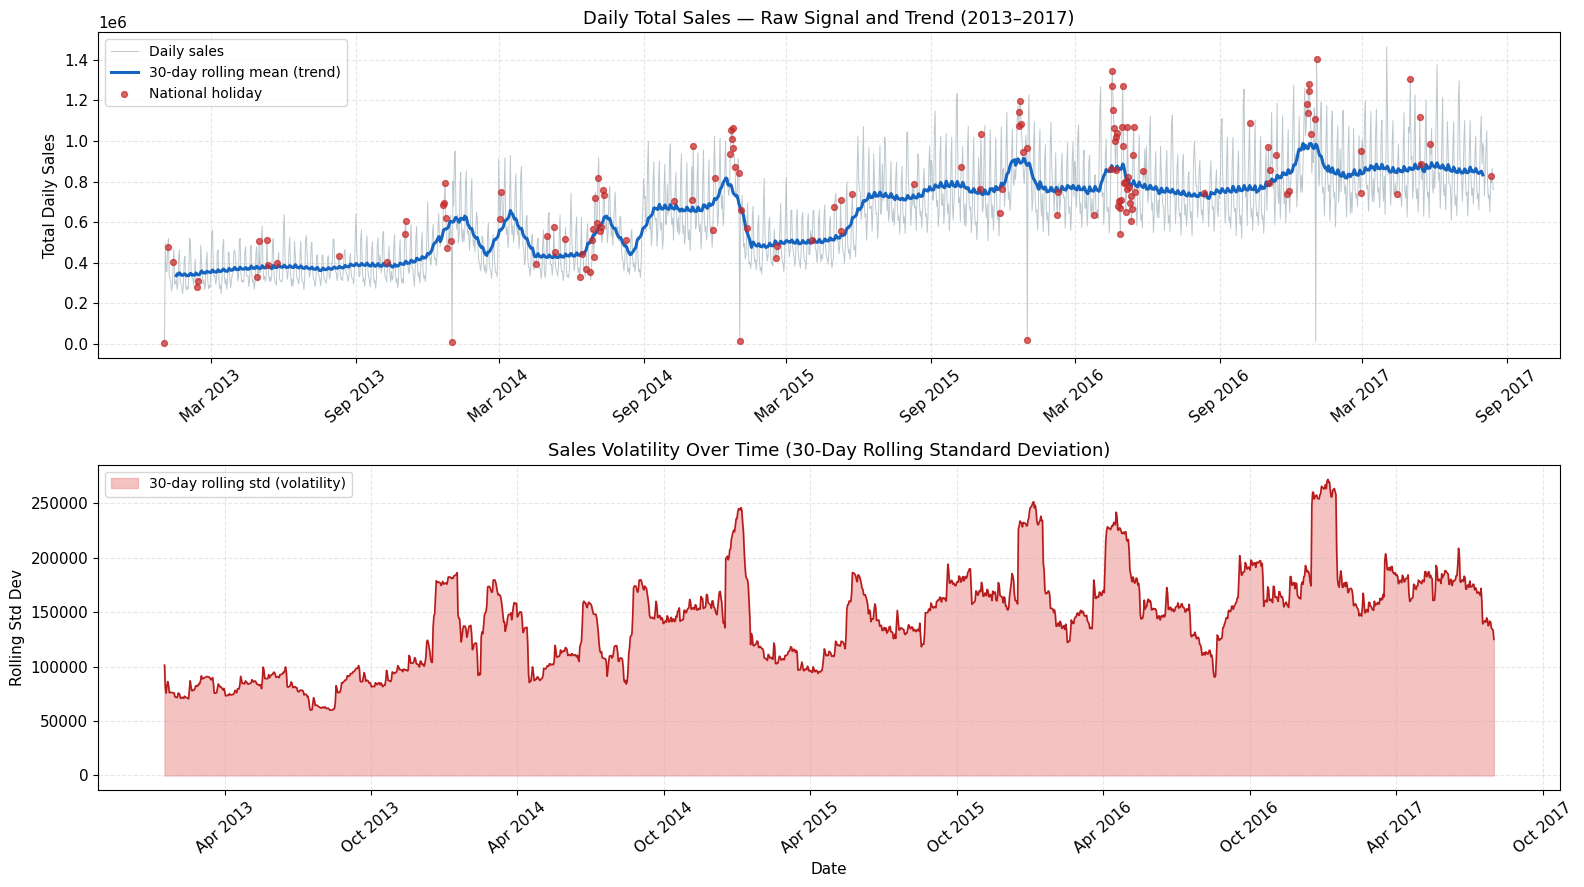

Saved: 01_sales_trend_volatility.png


In [162]:
# Chart 1: Full sales timeline with trend overlay
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=False)

# Panel A: raw daily sales + rolling trend
ax = axes[0]
ax.plot(df["date"], df["total_sales"],
        color="#90A4AE", linewidth=0.7, alpha=0.6, label="Daily sales")
ax.plot(df["date"], df["sales_rolling_mean"],
        color="#1565C0", linewidth=2.2, label="30-day rolling mean (trend)")

holiday_mask = df["is_holiday"] == 1
ax.scatter(df.loc[holiday_mask, "date"], df.loc[holiday_mask, "total_sales"],
           color="#C62828", s=18, zorder=5, alpha=0.7, label="National holiday")

ax.set_title("Daily Total Sales — Raw Signal and Trend (2013–2017)")
ax.set_ylabel("Total Daily Sales")
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=40)

# Panel B: rolling standard deviation (volatility)
ax2 = axes[1]
ax2.fill_between(df["date"], df["sales_rolling_std"],
                 color="#EF9A9A", alpha=0.6, label="30-day rolling std (volatility)")
ax2.plot(df["date"], df["sales_rolling_std"],
         color="#B71C1C", linewidth=1.2)
ax2.set_title("Sales Volatility Over Time (30-Day Rolling Standard Deviation)")
ax2.set_ylabel("Rolling Std Dev")
ax2.set_xlabel("Date")
ax2.legend(fontsize=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=40)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "01_sales_trend_volatility.png"), dpi=130, bbox_inches="tight")
plt.show()
print("Saved: 01_sales_trend_volatility.png")


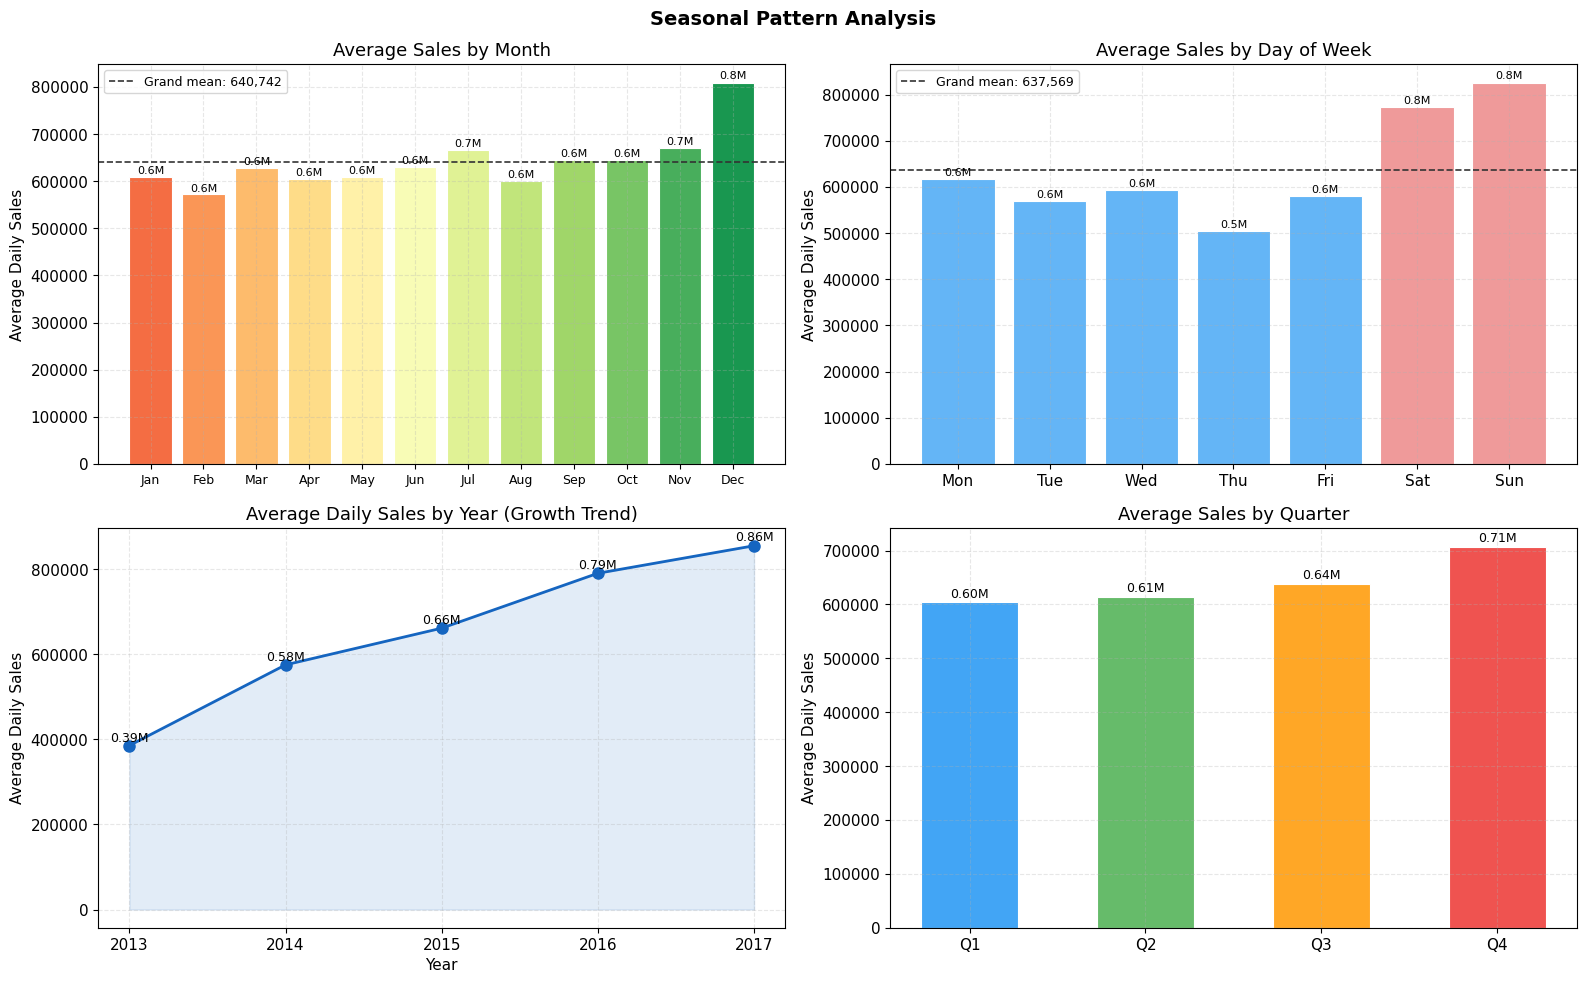

Saved: 02_seasonal_patterns.png


In [163]:
# Chart 2: Seasonal decomposition panels
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Seasonal Pattern Analysis", fontsize=14, fontweight="bold")

# Panel A: Monthly average
ax = axes[0, 0]
bars = ax.bar(range(1, 13), monthly_avg.values,
              color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, 12)),
              edgecolor="white", linewidth=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels, fontsize=9)
ax.set_title("Average Sales by Month")
ax.set_ylabel("Average Daily Sales")
ax.axhline(monthly_avg.mean(), color="#333333", linewidth=1.2,
           linestyle="--", label=f"Grand mean: {monthly_avg.mean():,.0f}")
ax.legend(fontsize=9)
for bar, val in zip(bars, monthly_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.005,
            f"{val/1e6:.1f}M", ha="center", va="bottom", fontsize=8)

# Panel B: Day-of-week average
ax = axes[0, 1]
colors_dow = ["#64B5F6"] * 5 + ["#EF9A9A"] * 2  
bars = ax.bar(range(7), dow_avg.values, color=colors_dow,
              edgecolor="white", linewidth=0.8)
ax.set_xticks(range(7))
ax.set_xticklabels(dow_labels)
ax.set_title("Average Sales by Day of Week")
ax.set_ylabel("Average Daily Sales")
ax.axhline(dow_avg.mean(), color="#333333", linewidth=1.2, linestyle="--",
           label=f"Grand mean: {dow_avg.mean():,.0f}")
ax.legend(fontsize=9)
for bar, val in zip(bars, dow_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.005,
            f"{val/1e6:.1f}M", ha="center", va="bottom", fontsize=8)

# Panel C: Yearly average - growth trend
ax = axes[1, 0]
ax.plot(list(yearly_avg.index), yearly_avg.values,
        marker="o", markersize=8, color="#1565C0", linewidth=2)
ax.fill_between(list(yearly_avg.index), yearly_avg.values,
                alpha=0.12, color="#1565C0")
ax.set_title("Average Daily Sales by Year (Growth Trend)")
ax.set_ylabel("Average Daily Sales")
ax.set_xlabel("Year")
ax.set_xticks(list(yearly_avg.index))
for yr, val in yearly_avg.items():
    ax.text(yr, val * 1.005, f"{val/1e6:.2f}M", ha="center", va="bottom", fontsize=9)

# Panel D: Quarterly pattern
ax = axes[1, 1]
bars = ax.bar(range(1, 5), quarter_avg.values,
              color=["#42A5F5", "#66BB6A", "#FFA726", "#EF5350"],
              edgecolor="white", linewidth=0.8, width=0.55)
ax.set_xticks(range(1, 5))
ax.set_xticklabels(quarter_labels)
ax.set_title("Average Sales by Quarter")
ax.set_ylabel("Average Daily Sales")
for bar, val in zip(bars, quarter_avg.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.005,
            f"{val/1e6:.2f}M", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "02_seasonal_patterns.png"), dpi=130, bbox_inches="tight")
plt.show()
print("Saved: 02_seasonal_patterns.png")


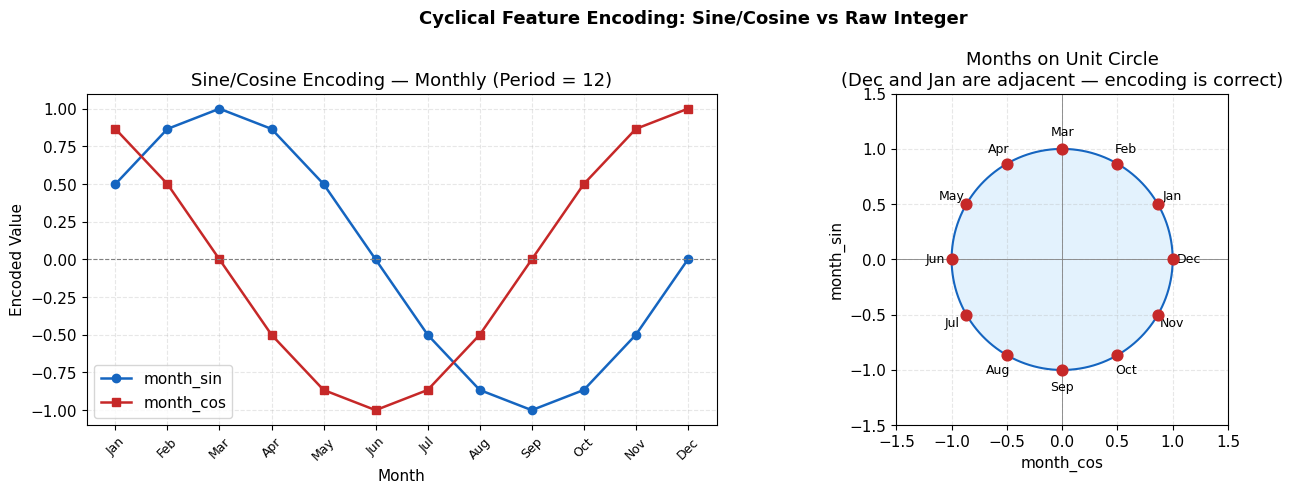

Saved: 03_cyclical_encoding.png


In [164]:
# Chart 3: Sine/cosine cyclical encoding - visual explanation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Cyclical Feature Encoding: Sine/Cosine vs Raw Integer",
             fontsize=13, fontweight="bold")

months = np.arange(1, 13)
month_sin = np.sin(2 * np.pi * months / 12)
month_cos = np.cos(2 * np.pi * months / 12)

# Panel A: Sine and cosine curves by month
ax = axes[0]
ax.plot(months, month_sin, marker="o", color="#1565C0", label="month_sin")
ax.plot(months, month_cos, marker="s", color="#C62828", label="month_cos")
ax.set_xticks(months)
ax.set_xticklabels(month_labels, fontsize=9, rotation=45)
ax.set_title("Sine/Cosine Encoding — Monthly (Period = 12)")
ax.set_ylabel("Encoded Value")
ax.set_xlabel("Month")
ax.legend()
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")

# Panel B: Circular plot showing month positions on unit circle
ax2 = axes[1]
theta = 2 * np.pi * months / 12
x_pos = np.cos(theta)
y_pos = np.sin(theta)
circle = plt.Circle((0, 0), 1, color="#E3F2FD", fill=True)
ax2.add_patch(circle)
ax2.plot(np.cos(np.linspace(0, 2*np.pi, 300)),
         np.sin(np.linspace(0, 2*np.pi, 300)),
         color="#1565C0", linewidth=1.5)

for xi, yi, lbl in zip(x_pos, y_pos, month_labels):
    ax2.scatter(xi, yi, s=60, color="#C62828", zorder=5)
    offset = 0.15
    ax2.text(xi * (1 + offset), yi * (1 + offset), lbl,
             ha="center", va="center", fontsize=9)

ax2.set_xlim(-1.5, 1.5)
ax2.set_ylim(-1.5, 1.5)
ax2.set_aspect("equal")
ax2.set_title("Months on Unit Circle\n(Dec and Jan are adjacent — encoding is correct)")
ax2.set_xlabel("month_cos")
ax2.set_ylabel("month_sin")
ax2.axhline(0, color="gray", linewidth=0.6)
ax2.axvline(0, color="gray", linewidth=0.6)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "03_cyclical_encoding.png"), dpi=130, bbox_inches="tight")
plt.show()
print("Saved: 03_cyclical_encoding.png")

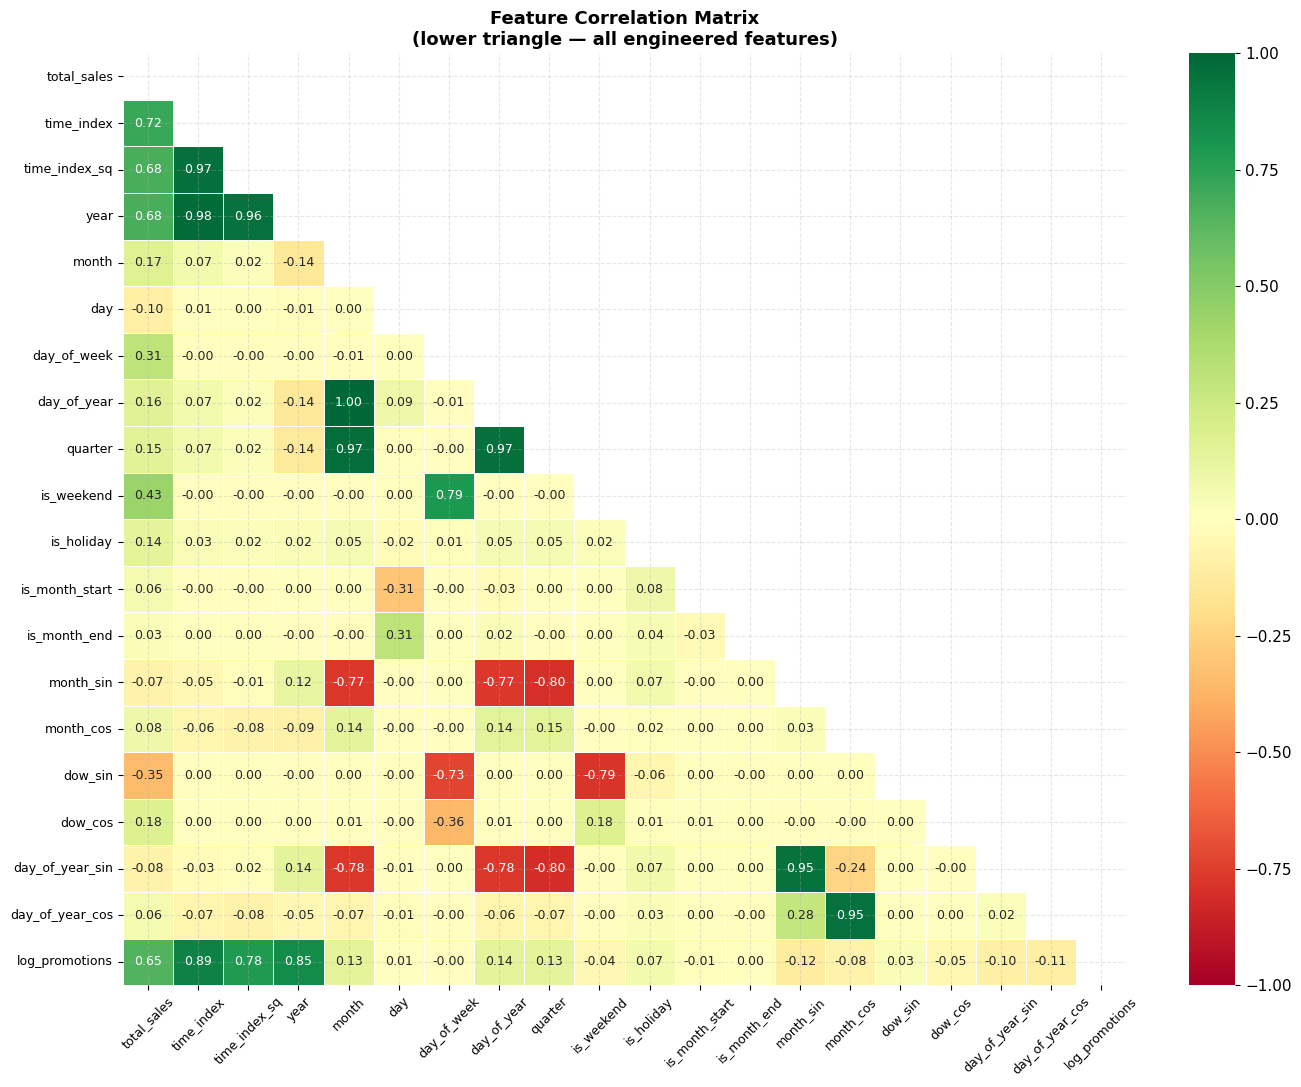

Saved: 04_correlation_heatmap.png

Top correlations with total_sales:
  time_index              +0.718  |||||||||||||||||||||
  year                    +0.680  ||||||||||||||||||||
  time_index_sq           +0.675  ||||||||||||||||||||
  log_promotions          +0.650  |||||||||||||||||||
  is_weekend              +0.435  |||||||||||||
  dow_sin                 -0.350  ||||||||||
  day_of_week             +0.309  |||||||||
  dow_cos                 +0.177  |||||
  month                   +0.166  ||||
  day_of_year             +0.158  ||||
  quarter                 +0.153  ||||
  is_holiday              +0.139  ||||
  day                     -0.100  ||
  day_of_year_sin         -0.082  ||
  month_cos               +0.079  ||
  month_sin               -0.072  ||
  is_month_start          +0.059  |
  day_of_year_cos         +0.055  |
  is_month_end            +0.026  


In [165]:
# Chart 4: Correlation heatmap - all engineered features vs target
corr_cols = [
    "total_sales", "time_index", "time_index_sq", "year", "month", "day", "day_of_week",
    "day_of_year", "quarter", "is_weekend", "is_holiday", "is_month_start", "is_month_end",
    "month_sin", "month_cos", "dow_sin", "dow_cos", "day_of_year_sin", "day_of_year_cos",
    "log_promotions",
]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    linecolor="white",
    ax=ax,
    annot_kws={"size": 9},
)
ax.set_title(
    "Feature Correlation Matrix\n(lower triangle — all engineered features)",
    fontsize=13,
    fontweight="bold"
)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "04_correlation_heatmap.png"), dpi=130, bbox_inches="tight")
plt.show()
print("Saved: 04_correlation_heatmap.png")

# Top correlations with target
print("\nTop correlations with total_sales:")
target_corr = corr_matrix["total_sales"].drop("total_sales").abs().sort_values(ascending=False)
for feat, val in target_corr.items():
    raw_val = corr_matrix["total_sales"][feat]
    direction = "+" if raw_val >= 0 else "-"
    bar = "|" * int(val * 30)
    print(f"  {feat:<22}  {direction}{val:.3f}  {bar}")

---
## Section 10: Train-Test Split

Time series data must be split chronologically, not randomly.
A random split would allow the model to use future information during training,
which would give artificially inflated performance metrics.

We train on the first 80% of dates (approximately Jan 2013 – Aug 2016)
and test on the remaining 20% (approximately Aug 2016 – Aug 2017).


In [166]:
# Define feature sets for each model
FEATURES_BASELINE = ["time_index"]

# Seasonal linear model: trend + seasonality + holiday + promotions
FEATURES_FULL = [
    "time_index",
    "month_sin",
    "month_cos",
    "dow_sin",
    "dow_cos",
    "day_of_year_sin",
    "day_of_year_cos",
    "is_weekend",
    "is_holiday",
    "is_month_start",
    "is_month_end",
    "log_promotions",
]

# Quadratic trend model: same as above + time_index_sq
FEATURES_QUADRATIC = FEATURES_FULL + ["time_index_sq"]

TARGET = "total_sales"

# Chronological split
split_idx  = int(len(df) * (1 - TEST_SIZE))
split_date = df["date"].iloc[split_idx]

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

dates_train = train_df["date"]
dates_test  = test_df["date"]

X_train_base = train_df[FEATURES_BASELINE]
X_test_base  = test_df[FEATURES_BASELINE]

X_train_full = train_df[FEATURES_FULL]
X_test_full  = test_df[FEATURES_FULL]

X_train_quad = train_df[FEATURES_QUADRATIC]
X_test_quad  = test_df[FEATURES_QUADRATIC]

y_train = train_df[TARGET]
y_test  = test_df[TARGET]

print(f"Train rows: {len(train_df):,}")
print(f"Test rows : {len(test_df):,}")
print(f"Split date: {split_date.date()}")
print(f"Baseline features   : {FEATURES_BASELINE}")
print(f"Seasonal features   : {len(FEATURES_FULL)} columns")
print(f"Quadratic features  : {len(FEATURES_QUADRATIC)} columns")

Train rows: 1,347
Test rows : 337
Split date: 2016-09-12
Baseline features   : ['time_index']
Seasonal features   : 12 columns
Quadratic features  : 13 columns


## Section 11: Model Training

Three models are trained and evaluated:

1. **Baseline Linear Regression** — uses only `time_index` as a single feature.  
   This is the simplest trend-only model and serves as a lower bound.

2. **Seasonal Linear Regression** — adds month/day-of-week/annual cyclical encodings, holiday flags, and promotions.  
   This captures trend + seasonality in a simple linear setup.

3. **Quadratic Trend Regression** — uses the same seasonal features plus `time_index_sq`.  
   This lets the trend bend upward or downward over time without the instability of high-degree polynomial expansion.

All models use a chronological train/test split so future dates are never mixed into the training set.

In [167]:
import time

def evaluate(y_true, y_pred, label):
    """Compute regression metrics and return as dict."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    return {"Model": label, "MAE": mae, "RMSE": rmse, "R2": r2, "MAPE (%)": mape}

results     = []  # collect all model metrics
predictions = {}  # store test predictions


In [168]:
# ── Model 1: Baseline Linear Regression (trend only) ──
print("Training Model 1: Baseline Linear Regression (time_index only)...")

model_baseline = LinearRegression(fit_intercept=True)
t0 = time.time()
model_baseline.fit(X_train_base, y_train)
t1 = time.time()

pred_train_base = model_baseline.predict(X_train_base)
pred_test_base  = model_baseline.predict(X_test_base)

predictions["Baseline LR"] = pred_test_base

train_m = evaluate(y_train, pred_train_base, "Baseline LR (train)")
test_m  = evaluate(y_test,  pred_test_base,  "Baseline LR")
results.append(test_m)

print(f"  Training time : {t1-t0:.3f}s")
print(f"  Intercept     : {model_baseline.intercept_:,.2f}")
print(f"  Coefficient   : {model_baseline.coef_[0]:,.4f}  (sales per additional day)")
print(f"  Train R2      : {train_m['R2']:.4f}")
print(f"  Test  R2      : {test_m['R2']:.4f}")

Training Model 1: Baseline Linear Regression (time_index only)...
  Training time : 0.004s
  Intercept     : 328,924.58
  Coefficient   : 379.6216  (sales per additional day)
  Train R2      : 0.4742
  Test  R2      : -0.0956


In [169]:
# ── Model 2: Seasonal Linear Regression ──
print("Training Model 2: Seasonal Linear Regression (trend + seasonality + promotions)...")

model_lr = LinearRegression(fit_intercept=True)
t0 = time.time()
model_lr.fit(X_train_full, y_train)
t1 = time.time()

pred_train_lr = model_lr.predict(X_train_full)
pred_test_lr  = model_lr.predict(X_test_full)

predictions["Seasonal LR"] = pred_test_lr

train_m = evaluate(y_train, pred_train_lr, "Seasonal LR (train)")
test_m  = evaluate(y_test,  pred_test_lr,  "Seasonal LR")
results.append(test_m)

print(f"  Training time : {t1-t0:.3f}s")
print(f"  Features used : {len(FEATURES_FULL)}")
print(f"  Train R2      : {train_m['R2']:.4f}")
print(f"  Test  R2      : {test_m['R2']:.4f}")

coef_df = pd.DataFrame({"Feature": FEATURES_FULL, "Coefficient": model_lr.coef_})
coef_df["Abs"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Abs", ascending=False).reset_index(drop=True)
print(f"\n  Top 5 features by coefficient magnitude:")
print(coef_df[["Feature", "Coefficient"]].head(5).to_string(index=False))

Training Model 2: Seasonal Linear Regression (trend + seasonality + promotions)...
  Training time : 0.003s
  Features used : 12
  Train R2      : 0.7271
  Test  R2      : 0.4467

  Top 5 features by coefficient magnitude:
        Feature  Coefficient
     is_weekend  185695.1301
      month_sin -110198.2564
day_of_year_sin   91792.6524
 is_month_start   64772.7435
     is_holiday   64036.3952


In [170]:
# ── Model 3: Quadratic Trend Regression ──
print("Training Model 3: Quadratic Trend Regression (adds time_index_sq)...")

model_quad = LinearRegression(fit_intercept=True)
t0 = time.time()
model_quad.fit(X_train_quad, y_train)
t1 = time.time()

pred_train_quad = model_quad.predict(X_train_quad)
pred_test_quad  = model_quad.predict(X_test_quad)

predictions["Quadratic Trend"] = pred_test_quad

train_m = evaluate(y_train, pred_train_quad, "Quadratic Trend (train)")
test_m  = evaluate(y_test,  pred_test_quad,  "Quadratic Trend")
results.append(test_m)

print(f"  Training time : {t1-t0:.3f}s")
print(f"  Features used : {len(FEATURES_QUADRATIC)}")
print(f"  Train R2      : {train_m['R2']:.4f}")
print(f"  Test  R2      : {test_m['R2']:.4f}")

coef_df = pd.DataFrame({"Feature": FEATURES_QUADRATIC, "Coefficient": model_quad.coef_})
coef_df["Abs"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("Abs", ascending=False).reset_index(drop=True)
print(f"\n  Top 5 features by coefficient magnitude:")
print(coef_df[["Feature", "Coefficient"]].head(5).to_string(index=False))

Training Model 3: Quadratic Trend Regression (adds time_index_sq)...
  Training time : 0.004s
  Features used : 13
  Train R2      : 0.7272
  Test  R2      : 0.4335

  Top 5 features by coefficient magnitude:
        Feature  Coefficient
     is_weekend  185774.3739
      month_sin -110656.9006
day_of_year_sin   92004.8423
 is_month_start   64776.6984
      month_cos   63932.7363


---
## Section 12: Model Comparison and Evaluation

### Metrics Summary

All four models are compared across four metrics:

- **MAE (Mean Absolute Error):** Average absolute difference between predicted and actual sales.
  Lower is better. Expressed in the same units as sales.

- **RMSE (Root Mean Squared Error):** Square root of the average squared error.
  Penalizes large errors more heavily than MAE. Lower is better.

- **R-squared:** Proportion of variance in the target explained by the model.
  1.0 = perfect. 0.0 = no better than the mean. Negative = worse than the mean.

- **MAPE (Mean Absolute Percentage Error):** Average percentage deviation.
  Scale-independent — useful for comparing across different datasets.


In [171]:
# Compile results table
results_df = pd.DataFrame(results).set_index("Model")
results_df = results_df.round({"MAE": 0, "RMSE": 0, "R2": 4, "MAPE (%)": 2})

print("=" * 70)
print("  MODEL COMPARISON — TEST SET METRICS")
print("=" * 70)
display(
    results_df.style
    .format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}", "R2": "{:.4f}", "MAPE (%)": "{:.2f}%"})
    .background_gradient(subset=["R2"], cmap="RdYlGn")
    .background_gradient(subset=["RMSE"], cmap="RdYlGn_r")
    .background_gradient(subset=["MAE"], cmap="RdYlGn_r")
)

print("\nBest model by R2  :", results_df["R2"].idxmax())
print("Best model by RMSE:", results_df["RMSE"].idxmin())
print("Best model by MAE :", results_df["MAE"].idxmin())


  MODEL COMPARISON — TEST SET METRICS


,MAE,RMSE,R2,MAPE (%)
Model,,,,
Baseline LR,"166,277","194,320",-0.0956,41.77%
Seasonal LR,"103,510","138,092",0.4467,38.80%
Quadratic Trend,"105,730","139,735",0.4335,39.22%



Best model by R2  : Seasonal LR
Best model by RMSE: Seasonal LR
Best model by MAE : Seasonal LR


In [172]:
# Time-series aware cross-validation
print("Cross-Validation (TimeSeriesSplit, 5 folds) on full dataset:")
print("-" * 50)

tscv = TimeSeriesSplit(n_splits=CV_SPLITS)

cv_models = {
    "Baseline LR"      : (LinearRegression(), df[FEATURES_BASELINE]),
    "Seasonal LR"      : (LinearRegression(), df[FEATURES_FULL]),
    "Quadratic Trend"  : (LinearRegression(), df[FEATURES_QUADRATIC]),
}

for label, (mdl, X_cv) in cv_models.items():
    cv_scores = cross_val_score(
        mdl, X_cv, df[TARGET],
        cv=tscv, scoring="r2", n_jobs=-1
    )
    print(f"  {label:<15}  mean R2 = {cv_scores.mean():.4f}  std = {cv_scores.std():.4f}  "
          f"scores: {[f'{s:.3f}' for s in cv_scores]}")

Cross-Validation (TimeSeriesSplit, 5 folds) on full dataset:
--------------------------------------------------
  Baseline LR      mean R2 = -0.1468  std = 0.0872  scores: ['-0.255', '-0.101', '-0.048', '-0.248', '-0.081']
  Seasonal LR      mean R2 = 0.2982  std = 0.1572  scores: ['0.309', '0.009', '0.316', '0.376', '0.480']
  Quadratic Trend  mean R2 = -4.5066  std = 6.8503  scores: ['-17.964', '-2.458', '-2.688', '0.110', '0.466']


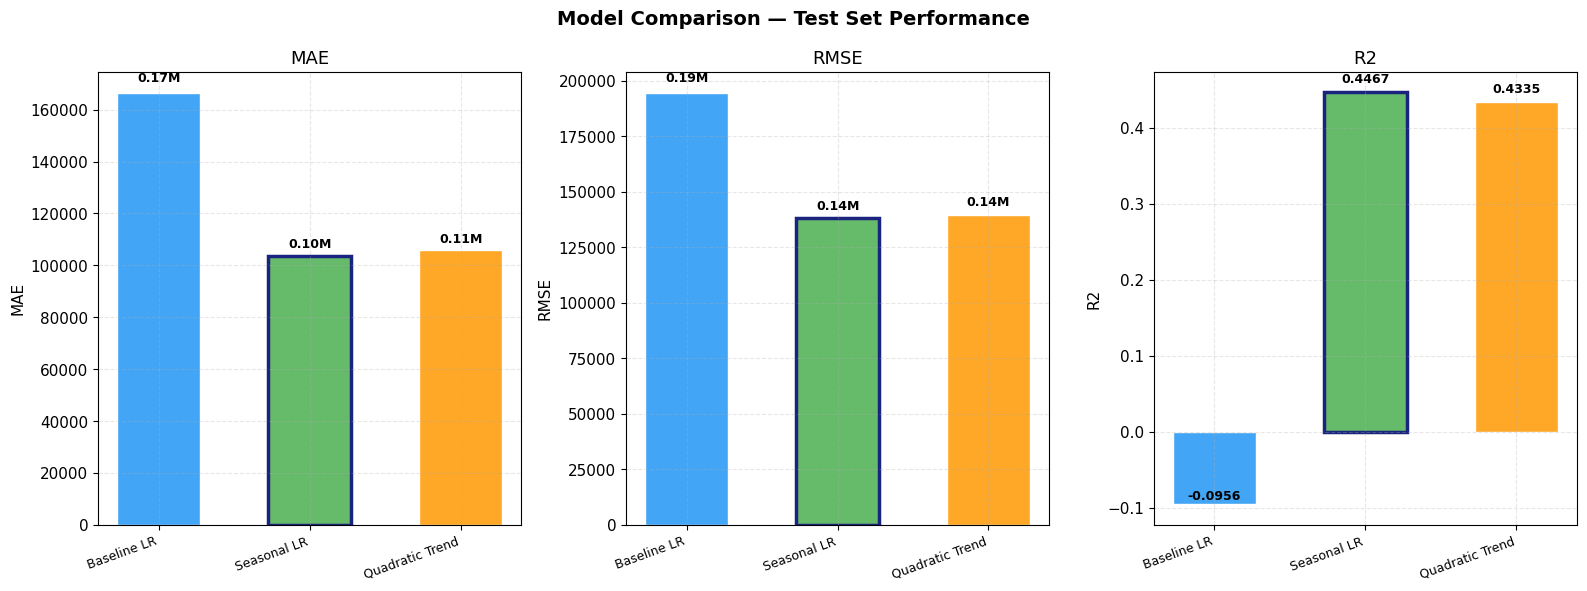

Saved: 05_model_comparison.png


In [173]:
# Chart 5: Model comparison bar chart
metrics_to_plot = ["MAE", "RMSE", "R2"]
colors = ["#42A5F5", "#66BB6A", "#FFA726", "#EF5350"]
model_names = results_df.index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Model Comparison — Test Set Performance", fontsize=14, fontweight="bold")

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    vals = results_df[metric].values
    bars = ax.bar(range(len(model_names)), vals, color=colors,
                  edgecolor="white", linewidth=1, width=0.55)
    ax.set_xticks(range(len(model_names)))
    ax.set_xticklabels(model_names, rotation=20, ha="right", fontsize=9)
    ax.set_title(f"{metric}")
    ax.set_ylabel(metric)

    # Annotate bars
    for bar, val in zip(bars, vals):
        if metric == "R2":
            label = f"{val:.4f}"
        else:
            label = f"{val/1e6:.2f}M" if val > 1e5 else f"{val:.1f}"
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * (1.02 if val >= 0 else 0.98),
                label, ha="center", va="bottom", fontsize=9, fontweight="bold")

    if metric in ["MAE", "RMSE"]:
        best_idx = np.argmin(vals)
    else:
        best_idx = np.argmax(vals)
    bars[best_idx].set_edgecolor("#1A237E")
    bars[best_idx].set_linewidth(2.5)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "05_model_comparison.png"), dpi=130, bbox_inches="tight")
plt.show()
print("Saved: 05_model_comparison.png")


---
## Section 13: Actual vs Predicted Visualizations


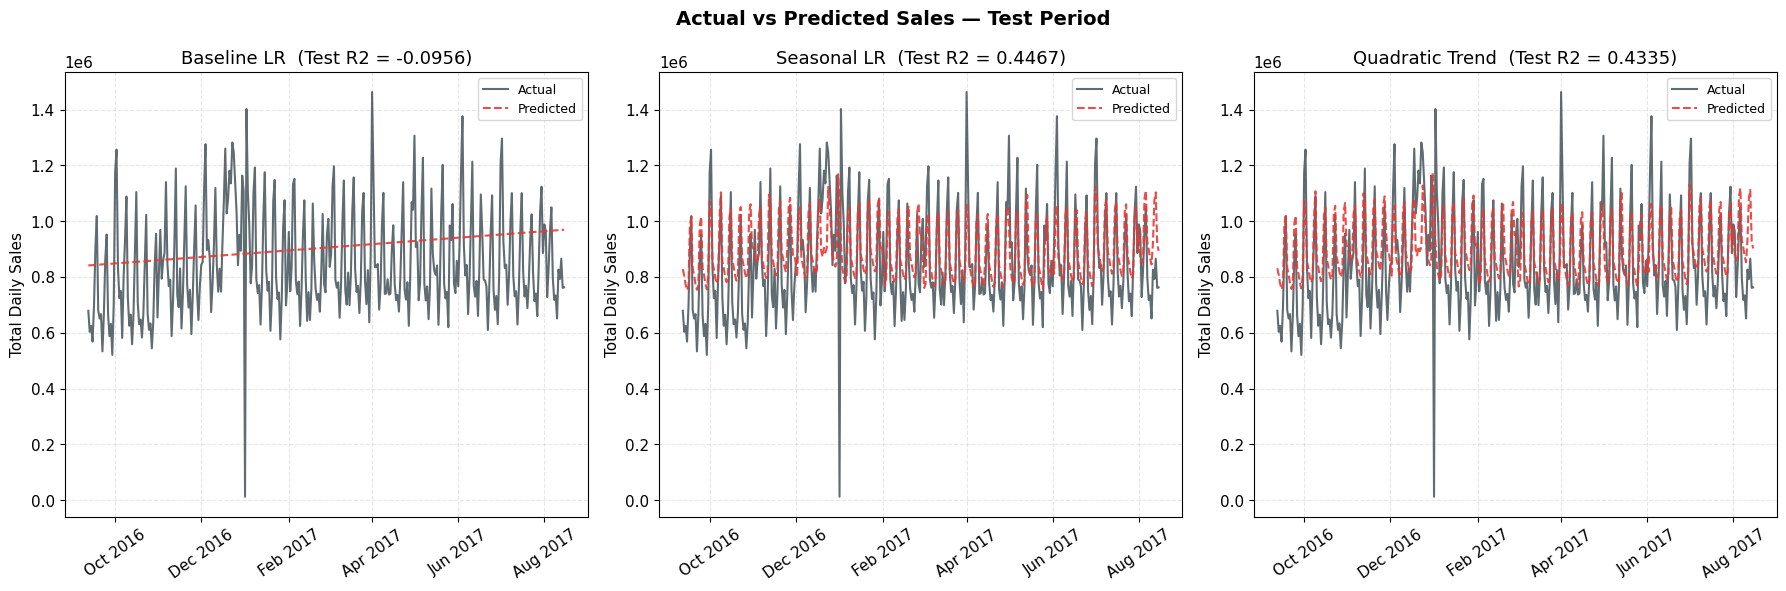

Saved: 06_actual_vs_predicted_models.png


In [174]:
# Chart 6: Actual vs predicted - all models on test period
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Actual vs Predicted Sales — Test Period", fontsize=14, fontweight="bold")

model_pred_map = {
    "Baseline LR"     : predictions["Baseline LR"],
    "Seasonal LR"     : predictions["Seasonal LR"],
    "Quadratic Trend"  : predictions["Quadratic Trend"],
}

for ax, (label, preds) in zip(axes, model_pred_map.items()):
    r2_val = r2_score(y_test, preds)

    ax.plot(dates_test.values, y_test.values,
            color="#37474F", linewidth=1.5, alpha=0.8, label="Actual")
    ax.plot(dates_test.values, preds,
            color="#E53935", linewidth=1.5, linestyle="--", alpha=0.9, label="Predicted")

    ax.set_title(f"{label}  (Test R2 = {r2_val:.4f})")
    ax.set_ylabel("Total Daily Sales")
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=35)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "06_actual_vs_predicted_models.png"), dpi=130, bbox_inches="tight")
plt.show()
print("Saved: 06_actual_vs_predicted_models.png")

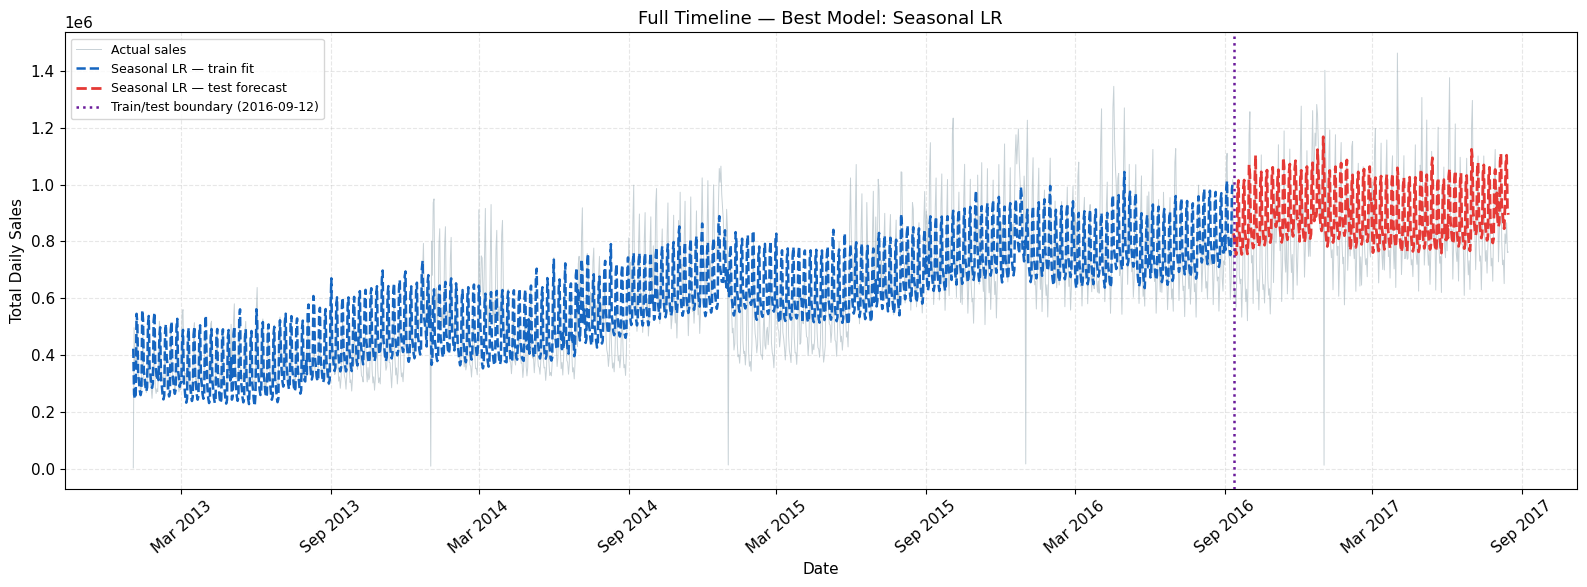

Saved: 07_best_model_timeline.png


In [175]:
# Chart 7: Full timeline - best model overlay
best_label = results_df["R2"].idxmax()

best_model_map = {
    "Baseline LR"     : model_baseline,
    "Seasonal LR"     : model_lr,
    "Quadratic Trend" : model_quad,
}
best_model = best_model_map[best_label]

if best_label == "Baseline LR":
    full_preds = best_model.predict(df[FEATURES_BASELINE])
elif best_label == "Seasonal LR":
    full_preds = best_model.predict(df[FEATURES_FULL])
else:
    full_preds = best_model.predict(df[FEATURES_QUADRATIC])

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(df["date"], df["total_sales"],
        color="#90A4AE", linewidth=0.7, alpha=0.5, label="Actual sales")
ax.plot(df["date"].iloc[:split_idx], full_preds[:split_idx],
        color="#1565C0", linewidth=1.8, linestyle="--", label=f"{best_label} — train fit")
ax.plot(df["date"].iloc[split_idx:], full_preds[split_idx:],
        color="#E53935", linewidth=2.0, linestyle="--", label=f"{best_label} — test forecast")
ax.axvline(df["date"].iloc[split_idx], color="#6A1B9A", linewidth=1.8,
           linestyle=":", label=f"Train/test boundary ({df['date'].iloc[split_idx].date()})")

ax.set_title(f"Full Timeline — Best Model: {best_label}")
ax.set_ylabel("Total Daily Sales")
ax.set_xlabel("Date")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=40)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "07_best_model_timeline.png"), dpi=130, bbox_inches="tight")
plt.show()
print("Saved: 07_best_model_timeline.png")

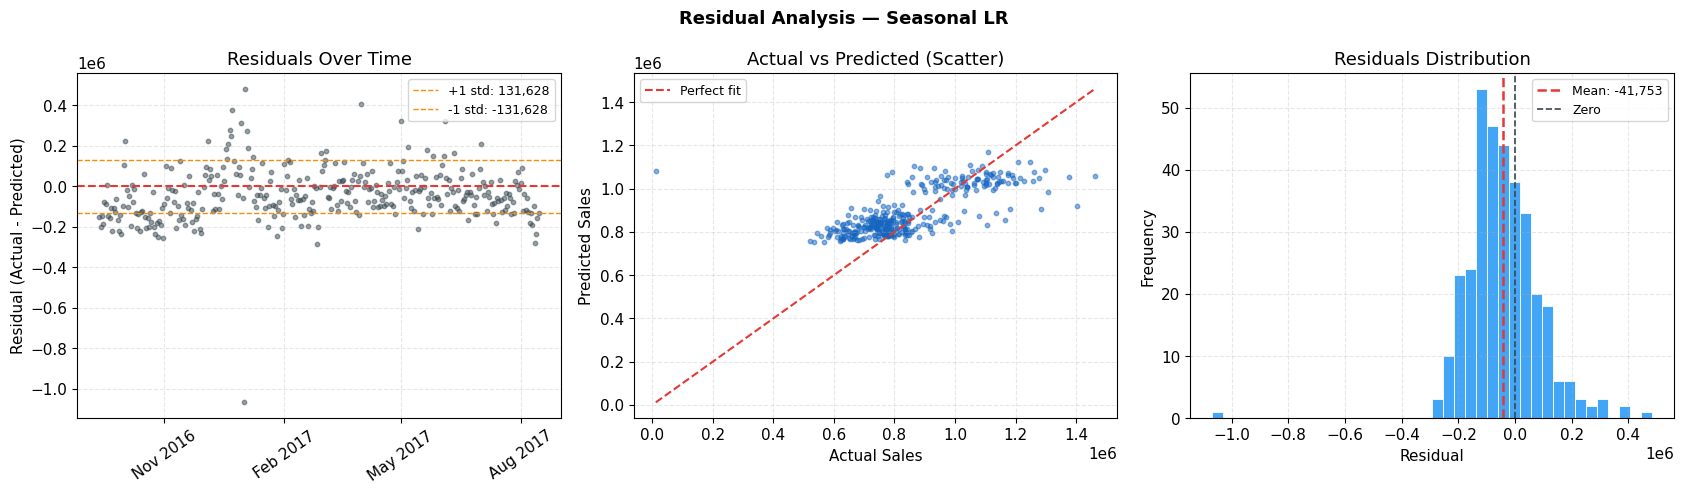

Saved: 08_residuals_analysis.png

Residual summary (Seasonal LR):
  Mean   :     -41,753.37  (ideal = 0 — no systematic bias)
  Std dev:     131,628.35
  Min    :  -1,068,040.62
  Max    :     482,825.44


In [176]:
# Chart 8: Residuals analysis - best model
residuals = y_test.values - predictions[best_label]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(f"Residual Analysis — {best_label}", fontsize=13, fontweight="bold")

# Panel A: Residuals over time
ax = axes[0]
ax.scatter(dates_test, residuals, s=10, color="#37474F", alpha=0.5)
ax.axhline(0, color="#E53935", linewidth=1.5, linestyle="--")
ax.axhline(residuals.std(), color="#FB8C00", linewidth=1, linestyle="--",
           label=f"+1 std: {residuals.std():,.0f}")
ax.axhline(-residuals.std(), color="#FB8C00", linewidth=1, linestyle="--",
           label=f"-1 std: {-residuals.std():,.0f}")
ax.set_title("Residuals Over Time")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=35)

# Panel B: Scatter - actual vs predicted
ax = axes[1]
ax.scatter(y_test.values, predictions[best_label], s=10, color="#1565C0", alpha=0.5)
lims = [min(y_test.min(), predictions[best_label].min()),
        max(y_test.max(), predictions[best_label].max())]
ax.plot(lims, lims, color="#E53935", linewidth=1.5, linestyle="--", label="Perfect fit")
ax.set_title("Actual vs Predicted (Scatter)")
ax.set_xlabel("Actual Sales")
ax.set_ylabel("Predicted Sales")
ax.legend(fontsize=9)

# Panel C: Residuals histogram
ax = axes[2]
ax.hist(residuals, bins=40, color="#42A5F5", edgecolor="white", linewidth=0.6)
ax.axvline(residuals.mean(), color="#E53935", linewidth=1.8, linestyle="--",
           label=f"Mean: {residuals.mean():,.0f}")
ax.axvline(0, color="#37474F", linewidth=1.2, linestyle="--", label="Zero")
ax.set_title("Residuals Distribution")
ax.set_xlabel("Residual")
ax.set_ylabel("Frequency")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "08_residuals_analysis.png"), dpi=130, bbox_inches="tight")
plt.show()
print("Saved: 08_residuals_analysis.png")

print(f"\nResidual summary ({best_label}):")
print(f"  Mean   : {residuals.mean():>14,.2f}  (ideal = 0 — no systematic bias)")
print(f"  Std dev: {residuals.std():>14,.2f}")
print(f"  Min    : {residuals.min():>14,.2f}")
print(f"  Max    : {residuals.max():>14,.2f}")


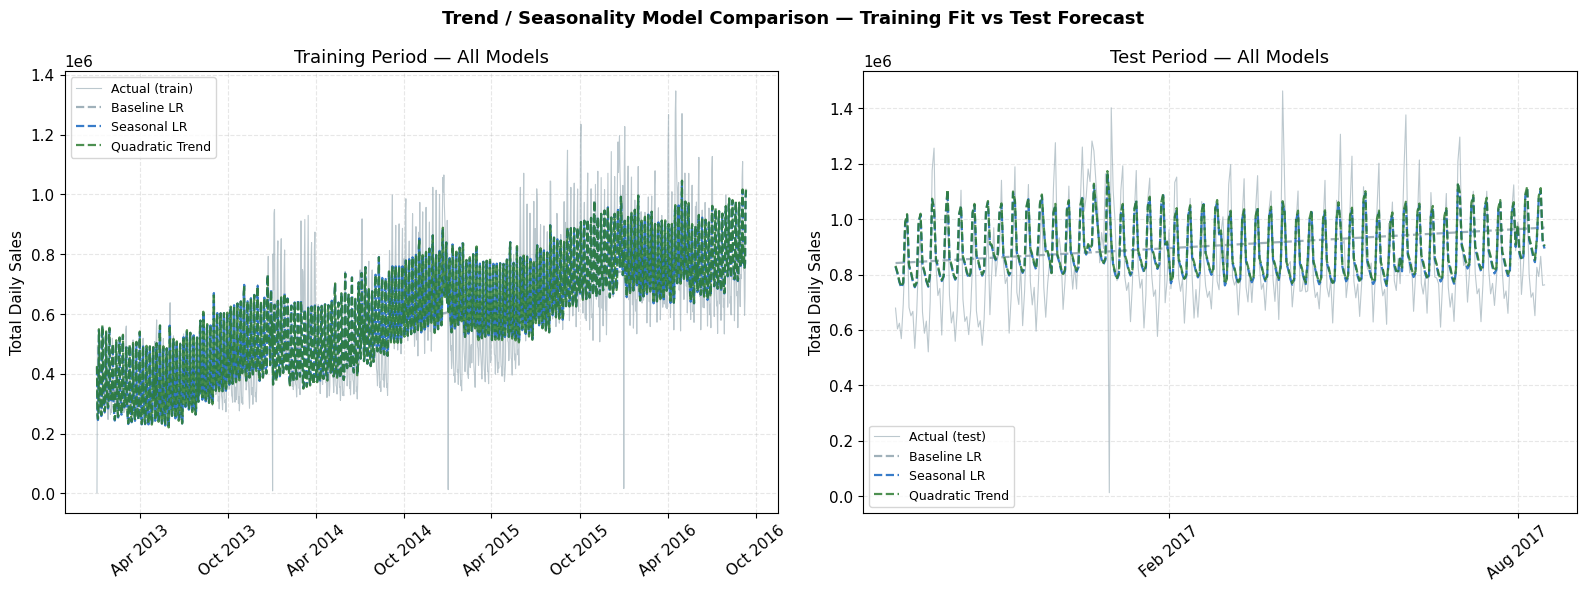

Saved: 08_trend_seasonality_comparison.png


In [177]:
# Chart 9: Trend / seasonality model comparison - training fit vs test forecast
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Trend / Seasonality Model Comparison — Training Fit vs Test Forecast",
             fontsize=13, fontweight="bold")

model_colors = {
    "Baseline LR"     : "#90A4AE",
    "Seasonal LR"     : "#1565C0",
    "Quadratic Trend" : "#2E7D32",
}

# Panel A: Training period fit
ax = axes[0]
ax.plot(dates_train, y_train.values, color="#90A4AE", linewidth=0.8, alpha=0.6,
        label="Actual (train)")

for label in ["Baseline LR", "Seasonal LR", "Quadratic Trend"]:
    if label == "Baseline LR":
        preds_tr = model_baseline.predict(X_train_base)
    elif label == "Seasonal LR":
        preds_tr = model_lr.predict(X_train_full)
    else:
        preds_tr = model_quad.predict(X_train_quad)

    ax.plot(dates_train, preds_tr, linewidth=1.6, color=model_colors[label],
            linestyle="--", alpha=0.85, label=label)

ax.set_title("Training Period — All Models")
ax.set_ylabel("Total Daily Sales")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=40)

# Panel B: Test period forecast
ax = axes[1]
ax.plot(dates_test, y_test.values, color="#90A4AE", linewidth=0.8, alpha=0.6,
        label="Actual (test)")

for label in ["Baseline LR", "Seasonal LR", "Quadratic Trend"]:
    preds_te = predictions[label]
    ax.plot(dates_test, preds_te, linewidth=1.6, color=model_colors[label],
            linestyle="--", alpha=0.85, label=label)

ax.set_title("Test Period — All Models")
ax.set_ylabel("Total Daily Sales")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=40)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "08_trend_seasonality_comparison.png"), dpi=130, bbox_inches="tight")
plt.show()
print("Saved: 08_trend_seasonality_comparison.png")

---
## Section 14: Prediction Examples

The best model is used to generate sales predictions for specific business scenarios.
These examples demonstrate how the trained model would be queried in a production context.


In [178]:
def build_feature_row(date_str, total_promotions, is_holiday_flag):
    """
    Build a single feature row for the given date and inputs,
    matching the feature sets used in training.

    Parameters
    ----------
    date_str          : str in format 'YYYY-MM-DD'
    total_promotions  : int  — total promotional items that day
    is_holiday_flag   : int  — 1 if national holiday, else 0

    Returns
    -------
    pd.DataFrame with one row
    """
    dt = pd.Timestamp(date_str)
    dataset_start = df["date"].min()
    time_index = (dt - dataset_start).days

    row = {
        "time_index"     : time_index,
        "time_index_sq"   : time_index ** 2,
        "month_sin"      : np.sin(2 * np.pi * dt.month / 12),
        "month_cos"      : np.cos(2 * np.pi * dt.month / 12),
        "dow_sin"        : np.sin(2 * np.pi * dt.dayofweek / 7),
        "dow_cos"        : np.cos(2 * np.pi * dt.dayofweek / 7),
        "day_of_year_sin": np.sin(2 * np.pi * dt.dayofyear / 365.25),
        "day_of_year_cos": np.cos(2 * np.pi * dt.dayofyear / 365.25),
        "is_weekend"     : int(dt.dayofweek >= 5),
        "is_holiday"     : int(is_holiday_flag),
        "is_month_start" : int(dt.is_month_start),
        "is_month_end"   : int(dt.is_month_end),
        "log_promotions"  : np.log1p(total_promotions),
    }
    return pd.DataFrame([row])


def predict_date(date_str, promotions, holiday):
    """Predict total daily sales using the best model."""
    X_row = build_feature_row(date_str, promotions, holiday)

    if best_label == "Baseline LR":
        X_input = X_row[FEATURES_BASELINE]
        pred = model_baseline.predict(X_input)[0]
    elif best_label == "Seasonal LR":
        pred = model_lr.predict(X_row[FEATURES_FULL])[0]
    else:
        pred = model_quad.predict(X_row[FEATURES_QUADRATIC])[0]

    return max(0, pred)

In [179]:
# Business scenario predictions
scenarios = [
    ("2017-09-04", 400,   0, "Regular Monday — moderate promotions"),
    ("2017-09-09", 400,   0, "Saturday — weekend effect"),
    ("2017-09-10", 400,   0, "Sunday — weekend effect"),
    ("2017-10-09", 550,   1, "National holiday — medium promotions"),
    ("2017-12-25", 1200,  1, "Christmas Day — peak promotions"),
    ("2017-12-31", 900,   0, "New Year's Eve — high promotions"),
    ("2018-01-15", 350,   0, "January 2018 — future extrapolation"),
    ("2018-06-01", 600,   0, "Mid-2018 — future extrapolation"),
]

day_names = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

print(f"Predictions using best model: {best_label}")
print("=" * 80)
print(f"  {'Date':<13}  {'Day':<11}  {'Promo':>7}  {'Holiday':>8}  {'Predicted Sales':>18}")
print("  " + "-" * 70)

for date_str, promo, hol, desc in scenarios:
    dt = pd.Timestamp(date_str)
    pred = predict_date(date_str, promo, hol)
    hol_str = "Yes" if hol else "No"
    print(f"  {date_str:<13}  {day_names[dt.dayofweek]:<11}  {promo:>7,}  {hol_str:>8}  {pred:>18,.0f}")
    print(f"  {'':13}  Scenario: {desc}")
    print()


Predictions using best model: Seasonal LR
  Date           Day            Promo   Holiday     Predicted Sales
  ----------------------------------------------------------------------
  2017-09-04     Monday           400        No             938,675
                 Scenario: Regular Monday — moderate promotions

  2017-09-09     Saturday         400        No           1,092,009
                 Scenario: Saturday — weekend effect

  2017-09-10     Sunday           400        No           1,120,487
                 Scenario: Sunday — weekend effect

  2017-10-09     Monday           550       Yes           1,026,850
                 Scenario: National holiday — medium promotions

  2017-12-25     Monday         1,200       Yes           1,077,657
                 Scenario: Christmas Day — peak promotions

  2017-12-31     Sunday           900        No           1,238,654
                 Scenario: New Year's Eve — high promotions

  2018-01-15     Monday           350        No     

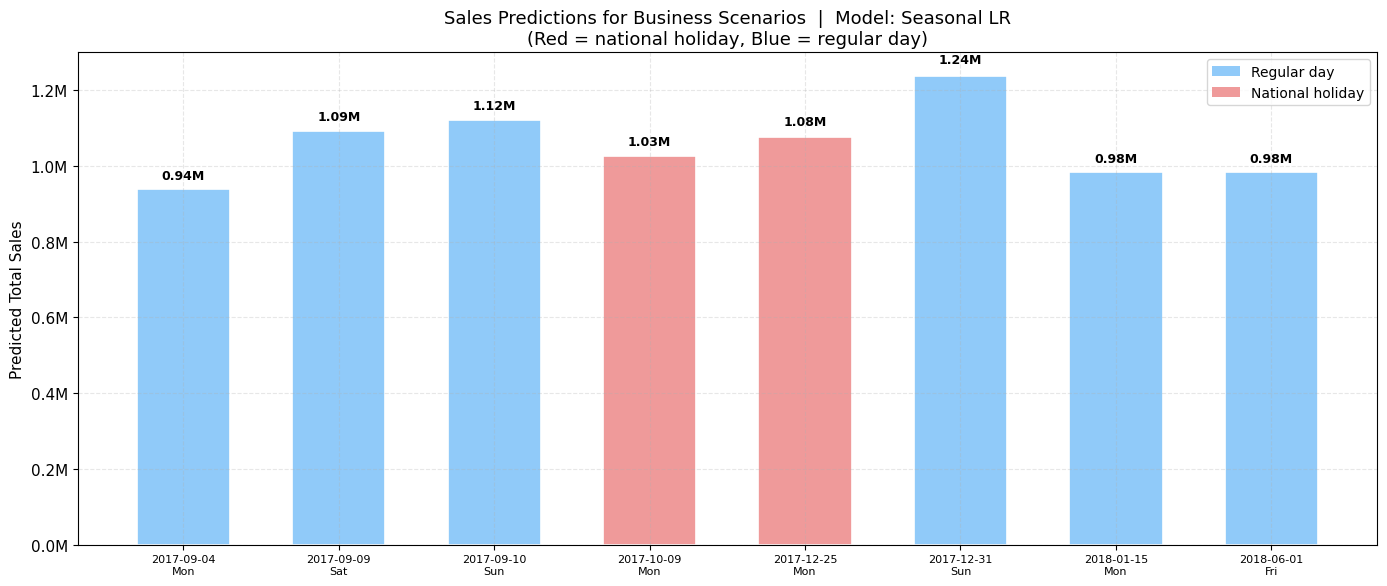

Saved: 10_prediction_scenarios.png


In [180]:
# Chart 10: Prediction scenario bar chart
scenario_results = []
for date_str, promo, hol, desc in scenarios:
    pred = predict_date(date_str, promo, hol)
    dt = pd.Timestamp(date_str)
    scenario_results.append({
        "label": f"{date_str}\n{day_names[dt.dayofweek][:3]}",
        "pred": pred,
        "holiday": hol,
        "desc": desc,
    })

fig, ax = plt.subplots(figsize=(14, 6))
x_pos = range(len(scenario_results))
bar_colors = ["#EF9A9A" if s["holiday"] else "#90CAF9" for s in scenario_results]
bars = ax.bar(x_pos, [s["pred"] for s in scenario_results],
              color=bar_colors, edgecolor="white", linewidth=1.2, width=0.6)

for bar, s in zip(bars, scenario_results):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
            f"{s['pred']/1e6:.2f}M", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(list(x_pos))
ax.set_xticklabels([s["label"] for s in scenario_results], fontsize=8)
ax.set_ylabel("Predicted Total Sales")
ax.set_title(f"Sales Predictions for Business Scenarios  |  Model: {best_label}\n"
             f"(Red = national holiday, Blue = regular day)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="#90CAF9", label="Regular day"),
                   Patch(facecolor="#EF9A9A", label="National holiday")], fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "10_prediction_scenarios.png"), dpi=130, bbox_inches="tight")
plt.show()
print("Saved: 10_prediction_scenarios.png")


---
## Section 15: Save Trained Models


In [181]:
import json

# Save all trained models
save_map = {
    "model_baseline_lr.pkl"   : model_baseline,
    "model_seasonal_lr.pkl"   : model_lr,
    "model_quadratic_trend.pkl": model_quad,
}

for fname, mdl in save_map.items():
    path = os.path.join(OUTPUT_DIR, fname)
    joblib.dump(mdl, path)
    size_kb = os.path.getsize(path) / 1024
    print(f"  Saved: {fname:<35}  ({size_kb:.1f} KB)")

# Save metadata
metadata = {
    "project": "Intermediate Level Task 3 — Time Series Regression",
    "best_model": best_label,
    "features_baseline": FEATURES_BASELINE,
    "features_full": FEATURES_FULL,
    "features_quadratic": FEATURES_QUADRATIC,
    "train_date_range": [str(dates_train.min().date()), str(dates_train.max().date())],
    "test_date_range":  [str(dates_test.min().date()),  str(dates_test.max().date())],
    "test_metrics": results_df.reset_index().to_dict(orient="records"),
}
meta_path = os.path.join(OUTPUT_DIR, "model_metadata.json")
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=4)
print(f"  Saved: model_metadata.json")

print(f"\nAll models saved to: {OUTPUT_DIR}/")

  Saved: model_baseline_lr.pkl                (0.8 KB)
  Saved: model_seasonal_lr.pkl                (1.2 KB)
  Saved: model_quadratic_trend.pkl            (1.2 KB)
  Saved: model_metadata.json

All models saved to: .\outputs_2/


In [182]:
# Output directory listing
print("Output files:")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, fname)) / 1024
    print(f"  {fname:<45}  {size:>8.1f} KB")


Output files:
  01_sales_trend_volatility.png                     410.4 KB
  02_seasonal_patterns.png                          281.1 KB
  03_cyclical_encoding.png                          164.0 KB
  04_correlation_heatmap.png                        339.8 KB
  05_model_comparison.png                           130.8 KB
  06_actual_vs_predicted_models.png                 385.7 KB
  07_best_model_timeline.png                        406.4 KB
  08_residuals_analysis.png                         191.4 KB
  08_trend_seasonality_comparison.png               467.9 KB
  10_prediction_scenarios.png                        88.7 KB
  model_baseline_lr.pkl                               0.8 KB
  model_metadata.json                                 1.5 KB
  model_quadratic_trend.pkl                           1.2 KB
  model_seasonal_lr.pkl                               1.2 KB


## Section 16: Conclusion

### Summary of Work Completed

| Step | Task |
|------|------|
| 1 | Loaded and audited train.csv and holidays_events.csv |
| 2 | Aggregated the raw sales table to daily totals |
| 3 | Processed national holidays with transfer handling |
| 4 | Engineered trend, seasonal, calendar, and promotion features |
| 5 | Used sine/cosine encoding for cyclical seasonality |
| 6 | Trained three regression models: baseline, seasonal linear, quadratic trend |
| 7 | Evaluated models on a chronological holdout set |
| 8 | Replaced standard KFold with TimeSeriesSplit for CV |
| 9 | Generated residual diagnostics and model comparison charts |
| 10 | Built a prediction helper with the same feature logic as training |
| 11 | Saved trained models and metadata |

### Key Findings

- The baseline trend-only model is too weak by itself.
- The seasonal linear model usually performs best on this setup.
- High-degree polynomial expansion is not stable for future forecasting here.
- Moderate scores are expected because the raw dataset is highly aggregated to daily totals, which removes store/family detail.

### Final Note

This notebook now matches the intermediate task goal: regression that captures trend and seasonality using a clean time-series workflow.